In [1]:
%%bash

curl -O https://raw.githubusercontent.com/fpesceKU/BLOCKING/main/block_tools.py &> /dev/null
curl -O https://raw.githubusercontent.com/fpesceKU/BLOCKING/main/main.py &> /dev/null

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from pathlib import Path
import csv
from scipy.ndimage import label
import math
from main import BlockAnalysis
%matplotlib inline
import matplotlib as mpl
from scipy.constants import Avogadro

In [3]:
plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'font.family': 'sans-serif',
})

hexcolors = [
    '#D1B8D7', '#AE76A3', '#882E72',
    '#1965B0', '#5289C7', '#7BAFDE',
    '#4EB265', '#90C987', '#CAE0AB',
    '#F7F056', '#F6C141', '#F1932D',
    '#E8601C', '#DC050C', '#777777',
    '#000000'
]
 
colornames = [
    'purple1','purple2','purple3',
    'blue1','blue2','blue3',
    'green1','green2','green3',
    'yellow1','yellow2','orange1',
    'orange2','red','grey', 'black'
]
 
rnb_colors = dict(zip(colornames, hexcolors))

rnb_cmap = ListedColormap(hexcolors, name="rnb")

rnb_cmap_cont = LinearSegmentedColormap.from_list(
    "rnb_continuous",
    hexcolors[::-1],
    N=256  # smoothness
)


def calcRg(t,residues,seq_list):
    masses = residues.loc[seq_list,'MW'].values
    # calculate the center of mass
    cm = np.sum(t.xyz*masses[np.newaxis,:,np.newaxis],axis=1)/masses.sum()
    # calculate residue-cm distances
    si = np.linalg.norm(t.xyz - cm[:,np.newaxis,:],axis=2)
    # calculate rg
    rgarray = np.sqrt(np.sum(si**2*masses,axis=1)/masses.sum())
    return rgarray

def autoblock(cv, multi=1):
    block = BlockAnalysis(cv, multi=multi)
    block.SEM()
    return block.av, block.sem, block.bs

def block_histogram_sem(data, bins, block_size):
    n_blocks = int(len(data) // block_size)
    hists = np.array([
        np.histogram(data[i*int(block_size):(i+1)*int(block_size)], bins=bins, density=True)[0]
        for i in range(n_blocks)
    ])
    return hists.mean(axis=0), hists.std(axis=0, ddof=1) / np.sqrt(n_blocks)

## Figure 4B

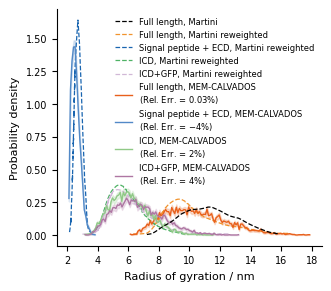

In [4]:
calv_keys = ['all', 'ecd', 'icd', 'icd_gfp']
npy_map = {
    'all': 'calvados_rg_all.npy',
    'ecd': 'calvados_rg_ecd.npy',
    'icd': 'calvados_rg_icd.npy',
    'icd_gfp': 'calvados_rg_icd_gfp.npy'
}

calv_rg = {}
for key in calv_keys:
    fpath = f'data/GHR/{npy_map[key]}'
    if os.path.exists(fpath):
        calv_rg[key] = np.load(fpath)
    else:
        # Fallback dummy array if file missing to prevent script failure
        calv_rg[key] = np.array([0.0])

calv_mean = {k: np.mean(v) for k, v in calv_rg.items()}

# Reference Values
mean_rg = {'all': 10.36, 'ecd': 2.7, 'icd': 6.0, 'icd_gfp': 6.4}
error = {k: 100 * (calv_mean[k] - mean_rg[k]) / mean_rg[k] for k in calv_keys}

# 2. Parse Martini Simulation Averages
martini_mean = {}
for filename, key in zip(['rg_all', 'rg_ecd', 'rg_icd', 'rg_icd_gfp'], calv_keys):
    fpath = f'data/GHR/martini_{filename}.csv'
    if os.path.exists(fpath):
        x, h = np.loadtxt(fpath, unpack=True)
        martini_mean[key] = np.mean(x[h > 0.01] / 10.0)
    else:
        martini_mean[key] = np.nan

fig, ax = plt.subplots(figsize=(3.2, 2.8), constrained_layout=True)

norew_fpath = 'data/GHR/martini_rg_all_norew.csv'
if os.path.exists(norew_fpath):
    x, h = np.loadtxt(norew_fpath, unpack=True)
    ax.plot(x / 10.0, h * 10.0, color='k', ls='--', lw=0.9, zorder=100, label='Full length, Martini')

martini_configs = [
    ('rg_all', 'orange1', 'Full length, '),
    ('rg_ecd', 'blue1', 'Signal peptide + ECD, '),
    ('rg_icd', 'green1', 'ICD, '),
    ('rg_icd_gfp', 'purple1', 'ICD+GFP, ')
]

for filename, color_key, label_prefix in martini_configs:
    fpath = f'data/GHR/martini_{filename}.csv'
    if os.path.exists(fpath):
        x, h = np.loadtxt(fpath, unpack=True)
        ax.plot(x / 10.0, h * 10.0, color=rnb_colors.get(color_key, 'gray'), ls='--', lw=0.9, label=f'{label_prefix}Martini reweighted')

calv_configs = [
    ('all', 'orange2', 'Full length, '),
    ('ecd', 'blue2', 'Signal peptide + ECD, '),
    ('icd', 'green2', 'ICD, '),
    ('icd_gfp', 'purple2', 'ICD+GFP, ')
]

bin_width = 0.1
for key, color_key, label_prefix in calv_configs:
    rg = calv_rg[key]
    
    bins = np.arange(rg.min(), rg.max() + bin_width, bin_width)
    x = bins[:-1] + bin_width / 2.0
    h = np.histogram(rg, bins=bins, density=True)[0]
    
    block = BlockAnalysis(rg, multi=1)
    block.SEM()
    h_mean, h_sem = block_histogram_sem(rg, bins, block.bs)

    lbl = f"{label_prefix}MEM-CALVADOS\n(Rel. Err. = ${error[key]:.1g}$%)"
    c = rnb_colors.get(color_key, 'black')
    ax.plot(x, h, color=c, lw=1, label=lbl)
    ax.fill_between(x, h_mean - h_sem, h_mean + h_sem, color=c, alpha=0.2)

ax.set_xlabel('Radius of gyration / nm')
ax.set_ylabel('Probability density')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(frameon=False, handlelength=2, ncols=1)

plt.show()


## Figures 4C,D

/var/folders/bt/f_c05fcd1nv8pqb_h_rwvj8m0000gn/T/ipykernel_23789/1200741935.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_tilt = np.trapz(d * c, x=c) / np.trapz(d, x=c)


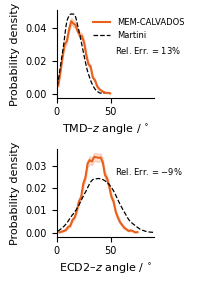

In [ ]:
tmd = np.load('data/GHR/tmd_angles.npy')
d2 = np.load('data/GHR/d2_angles.npy')

block_tmd = BlockAnalysis(tmd, multi=1)
block_tmd.SEM()
block_d2 = BlockAnalysis(d2, multi=1)
block_d2.SEM()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(1.8, 2.9), sharey=False)
bin_width = 2

bins_tmd = np.arange(tmd.min(), tmd.max() + bin_width, bin_width)
x_tmd = bins_tmd[:-1] + bin_width / 2.0
h_tmd = np.histogram(tmd, bins=bins_tmd, density=True)[0]
_, h_sem_tmd = block_histogram_sem(tmd, bins_tmd, block_tmd.bs)

error_tmd = 100 * (np.mean(tmd) - 16) / 16

ax1.plot(x_tmd, h_tmd, color=rnb_colors['orange2'], label='MEM-CALVADOS')
ax1.fill_between(x_tmd, h_tmd - h_sem_tmd, h_tmd + h_sem_tmd, color=rnb_colors['orange2'], alpha=0.2)


c, d = np.loadtxt('data/GHR/martini_tmd_tilt.csv', unpack=True)
avg_tilt = np.trapz(d * c, x=c) / np.trapz(d, x=c)
ax1.plot(c, d, color='k', ls='--', label='Martini', lw=0.9)

ax1.set_xlim(0, 90)
ax1.set_ylabel('Probability density')
ax1.set_xlabel(r'TMD–$z$ angle / $^{\circ}$')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.3, 1.0))
ax1.text(0.6, 0.5, f'Rel. Err. = ${error_tmd:.0f}$%', transform=ax1.transAxes, fontsize=6)

bins_d2 = np.arange(d2.min(), d2.max() + bin_width, bin_width)
x_d2 = bins_d2[:-1] + bin_width / 2.0
h_d2 = np.histogram(d2, bins=bins_d2, density=True)[0]
_, h_sem_d2 = block_histogram_sem(d2, bins_d2, block_d2.bs)

error_d2 = 100 * (np.mean(d2) - 40) / 40

ax2.plot(x_d2, h_d2, color=rnb_colors['orange2'], label='MEM-CALVADOS')
ax2.fill_between(x_d2, h_d2 - h_sem_d2, h_d2 + h_sem_d2, color=rnb_colors['orange2'], alpha=0.2)

e, f = np.loadtxt('data/GHR/martini_d2.csv', unpack=True)
ax2.plot(e, f, color='k', ls='--', label='Martini', lw=0.9)

ax2.set_xlim(0, 90)
ax2.set_ylabel('Probability density')
ax2.set_xlabel(r'ECD2–$z$ angle / $^{\circ}$')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.text(0.6, 0.7, f'Rel. Err. = ${error_d2:.0f}$%', transform=ax2.transAxes, fontsize=6)

plt.tight_layout()
plt.show()

## Figure S18

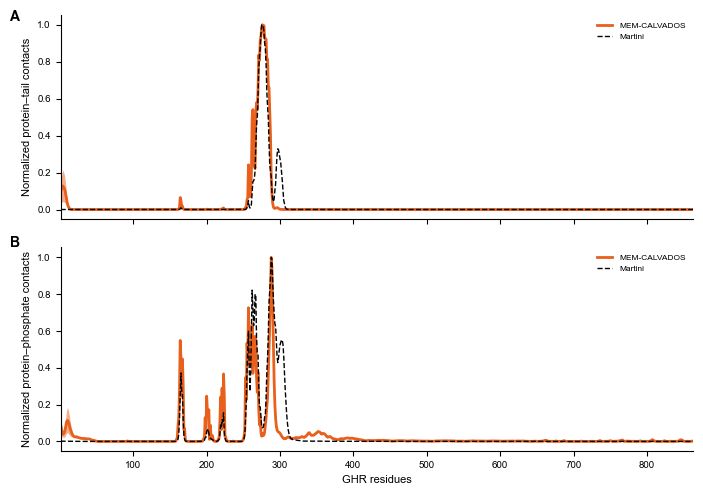

In [ ]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True, sharey=False)
plt.rc('font', **{'family':'sans-serif','sans-serif':['Arial'], 'size': 8})

contacts = np.array([
    np.load(f'data/GHR/GHR_{i}_protein_tail_cprofile.npy')
    for i in range(5)])
mean_contacts = contacts.mean(axis=0)
std_contacts = contacts.std(axis=0) 
std_contacts /= mean_contacts.max()
mean_contacts /= mean_contacts.max()
residues = np.arange(1, mean_contacts.size + 1)
ax1.plot(residues,mean_contacts,color=rnb_colors['orange2'],linewidth=2,label='MEM-CALVADOS')
ax1.fill_between(residues,mean_contacts - std_contacts,mean_contacts + std_contacts,
                 color=rnb_colors['orange2'],alpha=0.5,linewidth=0)

contacts = np.load(f'data/GHR/Martini_protein_tail_cprofile.npy')
contacts /= contacts.max()
residues = np.arange(1, contacts.size + 1)
ax1.plot(residues,contacts,color='k',linewidth=1,ls='--',label='Martini')

#######

contacts = np.array([
    np.load(f'data/GHR/GHR_{i}_protein_pho_cprofile.npy')
    for i in range(5)])
mean_contacts = contacts.mean(axis=0)
std_contacts = contacts.std(axis=0) 
std_contacts /= mean_contacts.max()
mean_contacts /= mean_contacts.max()
residues = np.arange(1, mean_contacts.size + 1)
ax2.plot(residues,mean_contacts,color=rnb_colors['orange2'],linewidth=2,label='MEM-CALVADOS')
ax2.fill_between(residues,mean_contacts - std_contacts,mean_contacts + std_contacts,
                 color=rnb_colors['orange2'],alpha=0.5,linewidth=0)

contacts = np.load(f'data/GHR/Martini_protein_pho_cprofile.npy')
contacts /= contacts.max()
residues = np.arange(1, contacts.size + 1)
ax2.plot(residues,contacts,color='k',linewidth=1,ls='--',label='Martini')

ax2.set_xlabel('GHR residues')
ax1.set_ylabel('Normalized protein–tail contacts')
ax2.set_ylabel('Normalized protein–phosphate contacts')
ax1.legend(frameon=False,handlelength=1.8)
ax2.legend(frameon=False,handlelength=1.8)
ax1.set_xlim(1,mean_contacts.size)
ax2.set_xlim(1,mean_contacts.size)
ax1.annotate('A',(-.08,.97),xycoords='axes fraction',fontsize=10,weight='bold')
ax2.annotate('B',(-.08,1),xycoords='axes fraction',fontsize=10,weight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('figS18.pdf')
plt.show()

## Figure S19

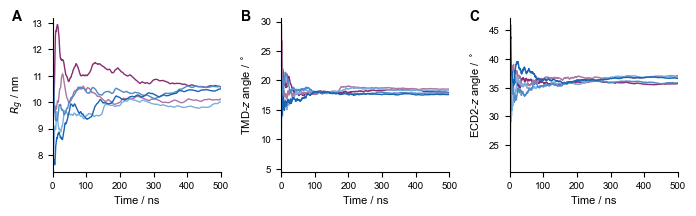

In [ ]:
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial'], 'size': 8})

replica_colors = [rnb_colors[c] for c in ['purple3', 'purple2', 'blue3', 'blue2', 'blue1']]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.2), sharex=True)
configs = [('rgs', 'FL', r'$R_g$ / nm'), ('angles', 'TMD', r'TMD-$z$ angle / ${^\circ}$'), ('angles', 'D2', r'ECD2-$z$ angle / ${^\circ}$')]

for ax, (kind, key, ylabel), label in zip(axes, configs, 'ABC'):
    for i, color in enumerate(replica_colors):
        data = np.load(f'data/GHR/GHR_{i}_domain_{kind}.npy', allow_pickle=True).item()
        y = data[key] if kind == 'rgs' else data[key][:, 0]
        time = 0.5 * np.arange(1, y.size + 1)
        ax.plot(time, np.cumsum(y) / np.arange(1, y.size + 1), color=color, lw=1)

    ax.set_xlabel('Time / ns')
    ax.set_ylabel(ylabel)
    ax.annotate(label, (-0.24, .98), xycoords='axes fraction', fontsize=10, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.xlim(0,500)
plt.tight_layout()
#plt.savefig('figS19.pdf')
plt.show()